In [1]:
import pandas as pd

from src.visualization.calibration.adaptive_make_endpoint_plots import adaptive_make_endpoint_plots
from src.evaluation.utils.get_predictions_and_labels_from_predictions_dataframe import get_predictions_and_labels_from_predictions_dataframe

from src.config_presets.tools.get_config import get_config

config = get_config('Daniel/MICCAI/Multi_tox')

src/config_presets/Base_config.yaml
src/config_presets/Daniel/MICCAI/Multi_tox.yaml


In [2]:
endpoints = ['Aspiration_M06', 'Dysphagia_M06', 'Sticky_M06', 'Taste_M06', 'Xerostomia_M06']

df_MT_preds_path = "/home/macraedc/results/MICCAI/Model_reproductions/Multi_tox/ensemble_predictions.csv"
df_ST_preds_folder = "/home/macraedc/results/MICCAI/ST_models"

MT_df = pd.read_csv(df_MT_preds_path, sep=';')
dfs_dict = {}
for endpoint in endpoints:
    dfs_dict[endpoint] = pd.read_csv(f"{df_ST_preds_folder}/{endpoint}/ensemble_predictions.csv", sep=';')

ST_df = None
for df in dfs_dict.values():
    print(df.columns)
    if ST_df is None:
        ST_df = df.copy()
    else:
        cols_to_add = ["PatientID"] + [
            c for c in df.columns
            if c != "Mode" and c not in ST_df.columns
        ]
        ST_df = ST_df.merge(df[cols_to_add], on="PatientID", how="outer")

ST_df = ST_df.sort_values("PatientID").reset_index(drop=True)
ST_df = ST_df.rename(columns=lambda c: c.replace("_true_true", "_true"))


Index(['PatientID', 'Mode', 'Aspiration_M06_pred', 'Aspiration_M06_true'], dtype='object')
Index(['PatientID', 'Mode', 'Dysphagia_M06_pred', 'Dysphagia_M06_true'], dtype='object')
Index(['PatientID', 'Mode', 'Sticky_M06_pred', 'Sticky_M06_true'], dtype='object')
Index(['PatientID', 'Mode', 'Taste_M06_pred', 'Taste_M06_true'], dtype='object')
Index(['PatientID', 'Mode', 'Xerostomia_M06_pred', 'Xerostomia_M06_true'], dtype='object')


In [3]:
ST_preds_dict, ST_labels_dict = get_predictions_and_labels_from_predictions_dataframe(config, ST_df, 'test')
MT_preds_dict, MT_labels_dict = get_predictions_and_labels_from_predictions_dataframe(config, MT_df, 'test')


row_dicts = [{
    'name'
}]

In [4]:
# init a plotting dict
plotting_dict = [{
    "name" : "ST",
    "labels" : ST_labels_dict,
    "preds" : ST_preds_dict
},
{
    "name" : "MT",
    "labels" : MT_labels_dict,
    "preds" : MT_preds_dict
}]

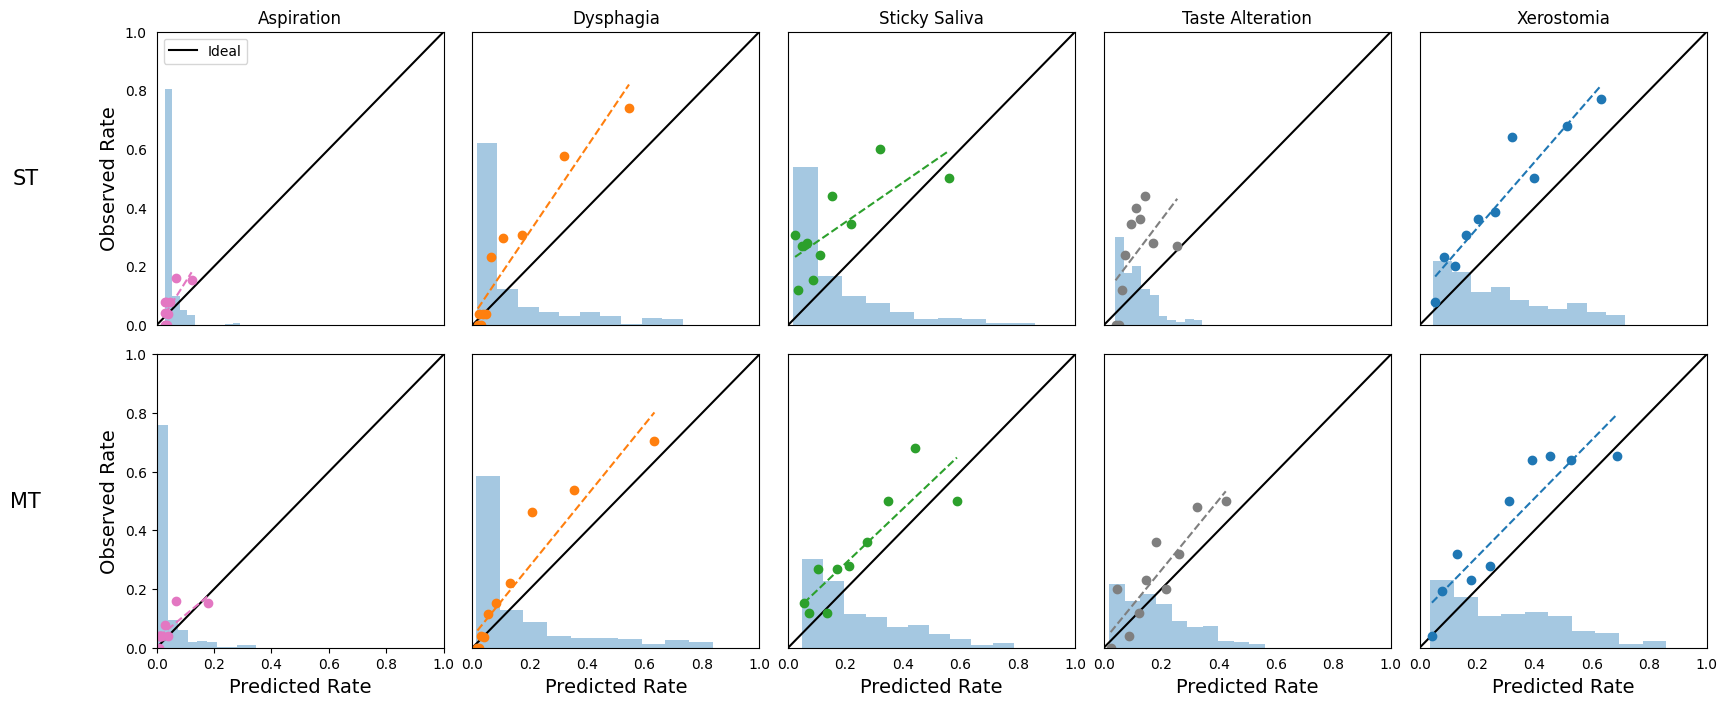

In [7]:
column_headers = ['Aspiration', 'Dysphagia', 'Sticky Saliva', 'Taste Alteration', 'Xerostomia']
fig = adaptive_make_endpoint_plots(config, plotting_dict, endpoints, return_fig=True)

name_map = dict(zip(endpoints, column_headers))

for i, ax in enumerate(fig.axes):
    title = ax.get_title()
    xlabel = ax.get_xlabel()
    ylabel = ax.get_ylabel()

    for old, new in name_map.items():
        title = title.replace(old, new)
        xlabel = xlabel.replace(old, new)
        ylabel = ylabel.replace(old, new)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if i > 0:
        ax.get_legend().remove()

fig.show()

for ax in fig.axes:
    ax.xaxis.label.set_size(14)
    ax.yaxis.label.set_size(14)

fig.savefig(f"/home/macraedc/MICCAI_figures/MICCAI_Figure_2.png", dpi=800, bbox_inches='tight')
fig.savefig(f"/home/macraedc/MICCAI_figures/MICCAI_Figure_2.pdf", bbox_inches='tight')
